<a href="https://colab.research.google.com/github/CleliaCaetano/-User-Behavior-Analysis-for-Optimizing-Engagement-on-Social-Media/blob/main/Copy_of_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the CSV file
df = pd.read_csv('Questionnaire.csv')

# CLEANING: Remove newlines and extra spaces so the names match your list
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# RENAME: Using the specific short names
df.rename(columns={
    "Timestamp": "timestamp",
    "Email address": "email",
    "1. Gender:": "gender",
    "2. Age:": "age",
    "3. Are you on social media?": "on_social_media",
    "4. How often do you use social media?": "social_media_frequency",
    "5. Which social media platforms do you use? (Select all that apply)": "platforms_used",
    "6. Which social media platform do you spend most time on?": "main_platform",
    "7. How often do you check online reviews and comments before making a purchase or hiring a service?": "check_reviews_frequency",
    "8. Which sources do you usually use to research reviews or opinions about products or services? (Select all that apply)": "review_sources",
    "9. Have you ever purchased a product or hired a service you didn’t really need, influenced by opinions or comments you read online?": "influenced_unnecessary_purchase",
    "10. Have you ever decided not to purchase a product or hire a service because of a negative review or comment?": "avoided_purchase_negative_review",
    "11. To what extent do you consider online reviews and opinions on social media comments influential in your purchasing or hiring decisions?": "reviews_influence_level",
    "12a. To what extent do you trust detailed comments from ordinary users (positive or negative)?": "trust_users",
    "12b. To what extent do you trust expert or influencer reviews?": "trust_experts",
    "13. To what extent do you consider online reviews and opinions on social media comments an important source of information before making purchasing decisions?": "reviews_importance",
    "14. In your opinion, to what extent can comments and opinions on social media create negative impacts or crises for a brand?": "negative_brand_impact"
}, inplace=True)

# CHECK COLLECTION DATES: Convert to datetime and find range
df['timestamp'] = pd.to_datetime(df['timestamp'])

first_date = df['timestamp'].min()
last_date = df['timestamp'].max()

print(f"Data collection started on: {first_date}")
print(f"Data collection ended on: {last_date}")
print(f"Total duration: {last_date - first_date}")

# DROP: Remove the email column (and timestamp if you are finished with it)
df.drop(columns=['timestamp', 'email'], inplace=True, errors='ignore')

# Verify the results
print("New Column Names:")
print(df.columns.tolist())

Data collection started on: 2025-12-22 15:43:17
Data collection ended on: 2026-01-01 17:18:23
Total duration: 10 days 01:35:06
New Column Names:
['gender', 'age', 'on_social_media', 'social_media_frequency', 'platforms_used', 'main_platform', 'check_reviews_frequency', 'review_sources', 'influenced_unnecessary_purchase', 'avoided_purchase_negative_review', 'reviews_influence_level', 'trust_users', 'trust_experts', 'reviews_importance', 'negative_brand_impact']


In [3]:
from tabulate import tabulate

# Show first 10 rows as a formatted table
print(tabulate(df.head(10), headers='keys', tablefmt='grid'))

+----+----------+-------+-------------------+--------------------------+-----------------------------------------+-----------------+---------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------+------------------------------------+---------------------------+---------------+-----------------+----------------------+-------------------------+
|    | gender   | age   | on_social_media   | social_media_frequency   | platforms_used                          | main_platform   | check_reviews_frequency   | review_sources                                                                                                                                                                                         | influenced_unnecessary_purchase   | avoided_purchase_negative_review   | reviews_influence_l

In [4]:
# check which columns contains categorical variables (object) and numerical variables (int64, float64).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   gender                            100 non-null    object
 1   age                               100 non-null    object
 2   on_social_media                   100 non-null    object
 3   social_media_frequency            100 non-null    object
 4   platforms_used                    100 non-null    object
 5   main_platform                     100 non-null    object
 6   check_reviews_frequency           100 non-null    object
 7   review_sources                    100 non-null    object
 8   influenced_unnecessary_purchase   100 non-null    object
 9   avoided_purchase_negative_review  100 non-null    object
 10  reviews_influence_level           100 non-null    object
 11  trust_users                       100 non-null    object
 12  trust_experts          

In [5]:
# display the missing values
df.isnull().sum()

,0
gender,0
age,0
on_social_media,0
social_media_frequency,0
platforms_used,0
main_platform,0
check_reviews_frequency,0
review_sources,0
influenced_unnecessary_purchase,0
avoided_purchase_negative_review,0


In [6]:
# calculate the number of unique values in each column.
df.nunique(axis = 0)

,0
gender,2
age,5
on_social_media,2
social_media_frequency,3
platforms_used,32
main_platform,11
check_reviews_frequency,5
review_sources,34
influenced_unnecessary_purchase,3
avoided_purchase_negative_review,3


### Exploratory Data Analysis (EDA): Visualize distributions

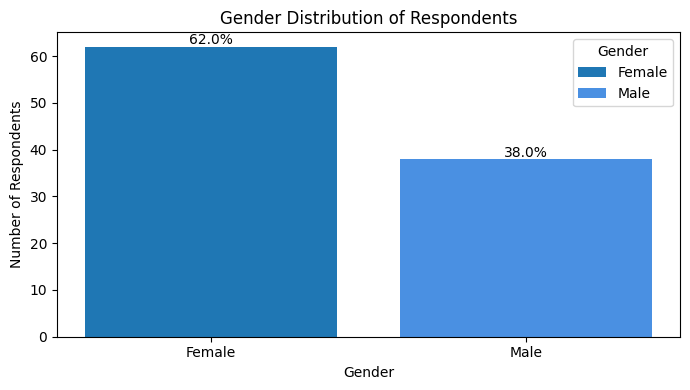

In [7]:
# Gender Distribution
gender_counts = df["gender"].value_counts()
total = gender_counts.sum()

# Shades of blue for bars (same number as unique genders)
colors = ['#1f77b4', '#4a90e2', '#6699cc', '#99ccff', '#cce5ff']

plt.figure(figsize=(7,4))
bars = plt.bar(gender_counts.index, gender_counts.values, color=colors)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    pct = height / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{pct:.1f}%', ha='center', fontsize=10)

# Update legend manually to match gender names
plt.legend(bars, gender_counts.index, title="Gender")

plt.title("Gender Distribution of Respondents")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

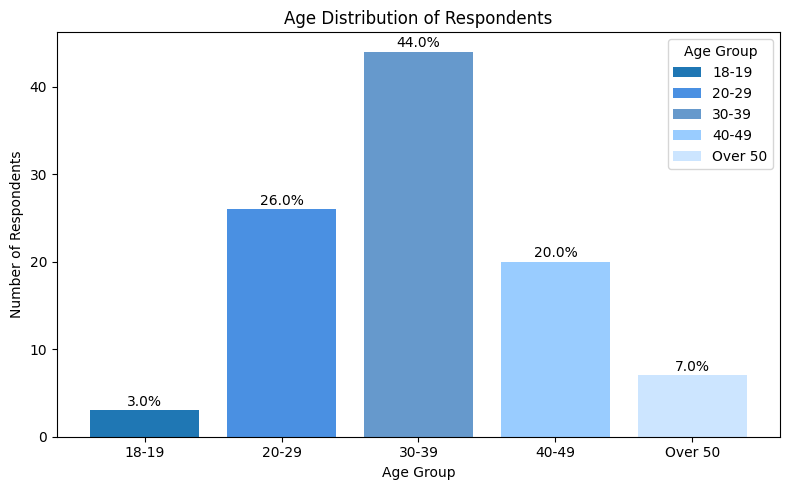

In [8]:
# Age Distribution
age_counts = df["age"].value_counts().sort_index()
total = age_counts.sum()

# Shades of blue (adjust length if you have more age groups)
colors = ['#1f77b4', '#4a90e2', '#6699cc', '#99ccff', '#cce5ff', '#b3d1ff']

plt.figure(figsize=(8,5))
bars = plt.bar(age_counts.index, age_counts.values, color=colors)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    pct = height / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{pct:.1f}%', ha='center', fontsize=10)

# Add legend manually with age groups
plt.legend(bars, age_counts.index, title="Age Group")

plt.title("Age Distribution of Respondents")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()


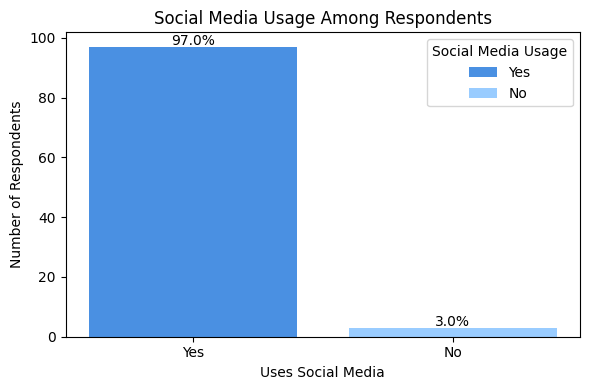

In [9]:
# Social Media Usage Distribution (counts)
sm_usage = df["on_social_media"].value_counts()
total = sm_usage.sum()

# Shades of blue (2 categories: Yes / No)
colors = ['#4a90e2', '#99ccff']

plt.figure(figsize=(6,4))
bars = plt.bar(sm_usage.index, sm_usage.values, color=colors)

# Add percentage labels on top
for bar in bars:
    height = bar.get_height()
    pct = height / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{pct:.1f}%', ha='center', fontsize=10)

# Add legend manually
plt.legend(bars, sm_usage.index, title="Social Media Usage")

plt.title("Social Media Usage Among Respondents")
plt.xlabel("Uses Social Media")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

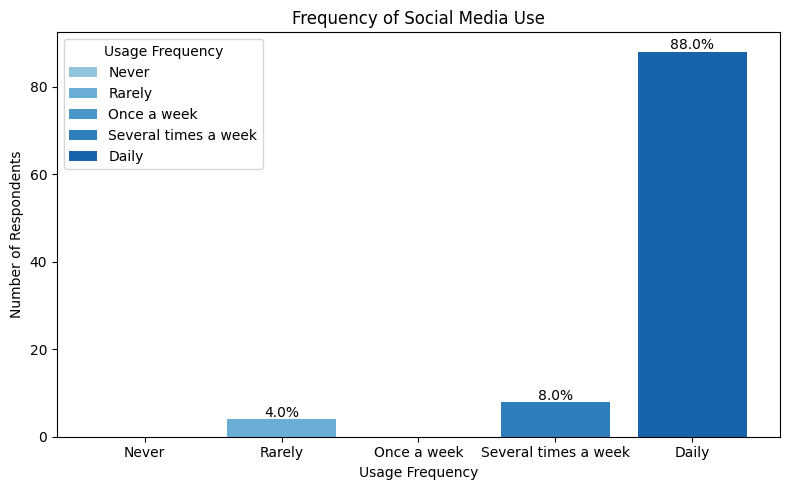

In [10]:
# Frequency of Social Media Use Count
# Example dataframe setup
freq_df = pd.DataFrame({
    'social_media_frequency': ['Never', 'Rarely', 'Once a week', 'Several times a week', 'Daily'],
    'social_media_frequency_numeric': [0, 1, 2, 3, 4],
    'count': [0, 4, 0, 8, 88]
})

total = freq_df['count'].sum()
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(freq_df)))

plt.figure(figsize=(8,5))
bars = plt.bar(freq_df['social_media_frequency'], freq_df['count'], color=colors)

# Add percentage labels
for bar, count in zip(bars, freq_df['count']):
    if count > 0:
        pct = count / total * 100
        plt.text(bar.get_x() + bar.get_width()/2, count + 0.5, f'{pct:.1f}%',
                 ha='center', fontsize=10)

# Correct legend: map bar to label manually
plt.legend(bars, freq_df['social_media_frequency'], title="Usage Frequency")

plt.title("Frequency of Social Media Use")
plt.xlabel("Usage Frequency")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

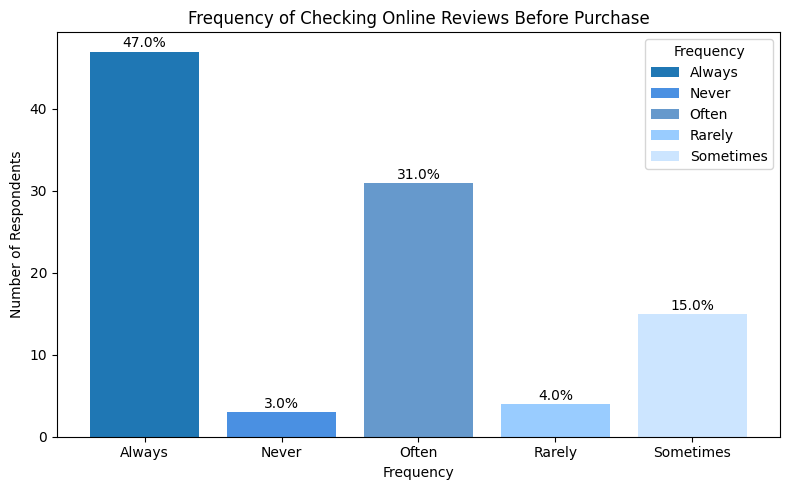

In [11]:
# Frequency of checking reviews counts

# 1. Define the logical order exactly as they appear in your data
# Adjust the strings in this list if your survey used different wording (e.g., "Often" vs "Very often")
logical_order = [
    "Always",
    "Often",
    "Sometimes",
    "Rarely",
    "Never"
]

review_freq = df["check_reviews_frequency"].value_counts().sort_index()
total = review_freq.sum()

# Shades of blue (adjust if you have more categories)
colors = ['#1f77b4', '#4a90e2', '#6699cc', '#99ccff', '#cce5ff']

plt.figure(figsize=(8,5))
bars = plt.bar(review_freq.index, review_freq.values, color=colors)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    pct = height / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{pct:.1f}%', ha='center', fontsize=10)

# Add legend manually
plt.legend(bars, review_freq.index, title="Frequency")

plt.title("Frequency of Checking Online Reviews Before Purchase")
plt.xlabel("Frequency")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()


Respondents' Main Social Media Platform:
                          Platform  Number of Respondents  Percentage (%)
main_platform_cleaned                                                    
Instagram                Instagram                     69            69.0
TikTok                      TikTok                     11            11.0
Facebook                  Facebook                     10            10.0
LinkedIn                  LinkedIn                      5             5.0
YouTube                    YouTube                      3             3.0
X (Twitter)            X (Twitter)                      1             1.0
WhatsApp                  WhatsApp                      1             1.0


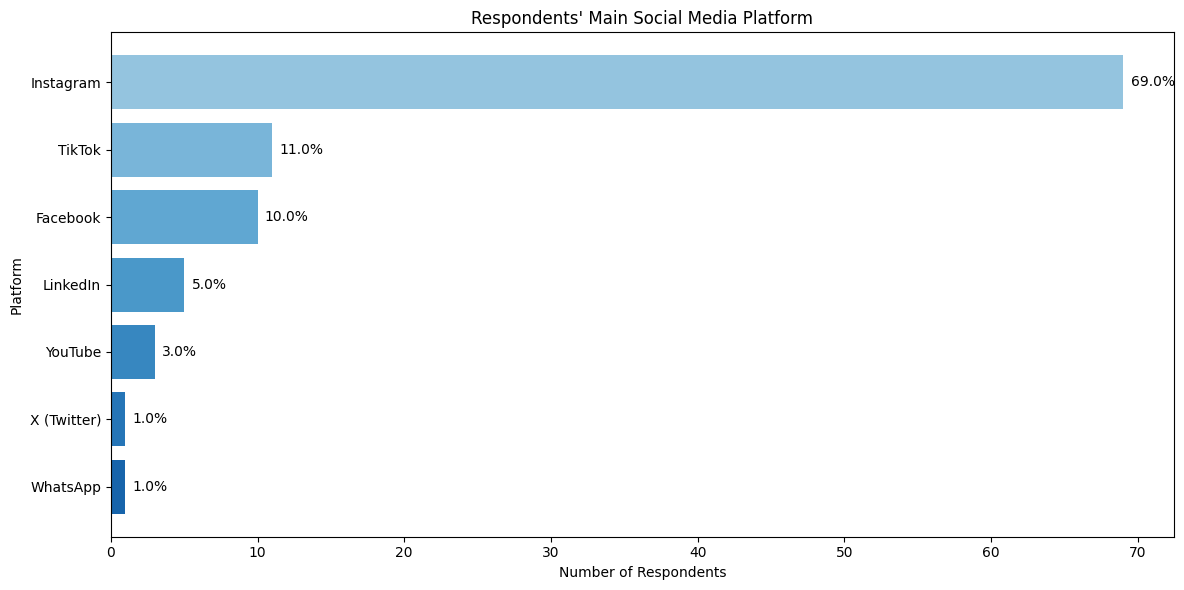

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Clean the main_platform column
# -------------------------------
def clean_main_platform(text):
    if pd.isna(text):
        return ""
    # Standardize names and remove extra spaces
    text = text.strip().lower()
    if 'linkedin' in text:
        return 'LinkedIn'
    elif 'whatsapp' in text:
        return 'WhatsApp'
    elif 'youtube' in text or 'youteub' in text:
        return 'YouTube'
    elif 'twitter' in text or 'x(' in text:
        return 'X (Twitter)'
    elif 'facebook' in text:
        return 'Facebook'
    elif 'instagram' in text:
        return 'Instagram'
    elif 'threads' in text:
        return 'Threads'
    elif 'tiktok' in text:
        return 'TikTok'
    elif 'reddit' in text:
        return 'Reddit'
    elif 'bluesky' in text:
        return 'Bluesky'
    else:
        return text.title()  # Capitalize other entries

df['main_platform_cleaned'] = df['main_platform'].apply(clean_main_platform)

# -------------------------------
# 2️⃣ Count totals and percentages
# -------------------------------
main_platform_counts = df['main_platform_cleaned'].value_counts().sort_values(ascending=False)
total_participants = len(df)

main_platform_summary = pd.DataFrame({
    'Platform': main_platform_counts.index,
    'Number of Respondents': main_platform_counts.values,
    'Percentage (%)': (main_platform_counts / total_participants * 100).round(1)
})

print("Respondents' Main Social Media Platform:")
print(main_platform_summary)

# -------------------------------
# 3️⃣ Horizontal bar chart
# -------------------------------
plt.figure(figsize=(12,6))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(main_platform_counts)))
bars = plt.barh(main_platform_counts.index, main_platform_counts.values, color=colors)

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    pct = width / total_participants * 100
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)

plt.title("Respondents' Main Social Media Platform")
plt.xlabel("Number of Respondents")
plt.ylabel("Platform")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()


Distribution of Social Media Platforms (Select All That Apply):
                Platform  Number of Selections  Percentage (%)
0              Instagram                    89            41.4
1               Facebook                    52            24.2
2                 Tiktok                    29            13.5
3             X(Twitter)                    17             7.9
4               Linkedin                     9             4.2
5                 Reddit                     9             4.2
6                Youtube                     3             1.4
7               Whatsapp                     2             0.9
8                Bluesky                     1             0.5
9             Uol.Com.Br                     1             0.5
10               Threads                     1             0.5
11               Youteub                     1             0.5
12  Youtube And Linkedin                     1             0.5


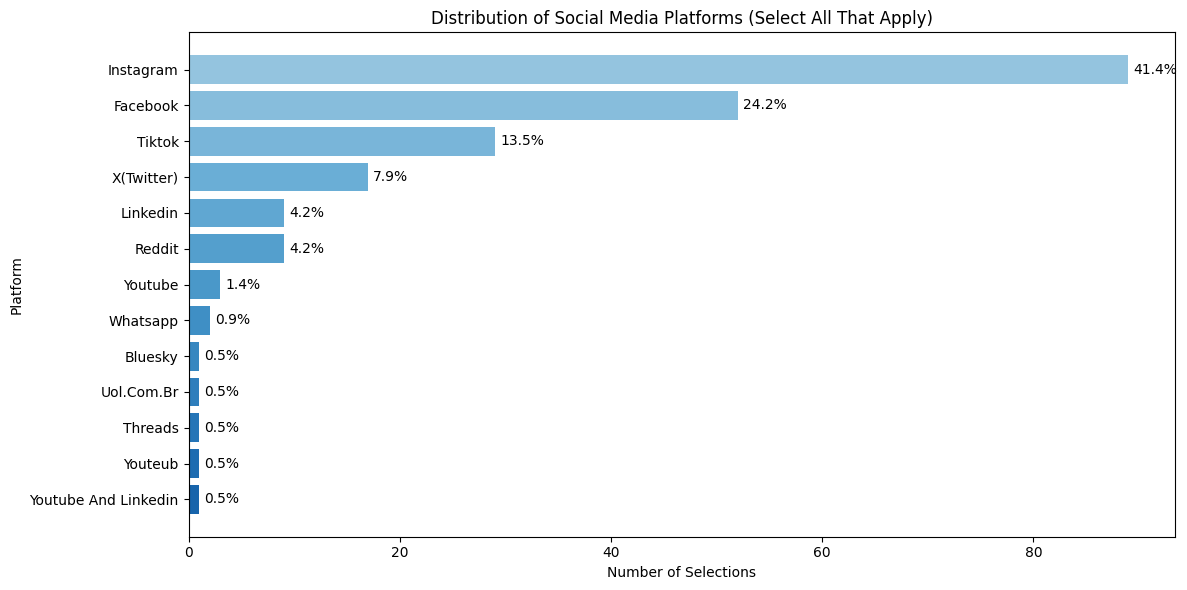

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Clean the platforms_used column
# -------------------------------
def clean_platforms(text):
    if pd.isna(text):
        return ""
    items = [t.strip().title() for t in str(text).split(',')]
    return "|".join(items)  # Pipe separator for dummies

df['platforms_cleaned'] = df['platforms_used'].apply(clean_platforms)

# -------------------------------
# 2️⃣ One-hot encode
# -------------------------------
platforms_df = df['platforms_cleaned'].str.get_dummies(sep='|')

# -------------------------------
# 3️⃣ Count totals and percentages
# -------------------------------
platform_counts = platforms_df.sum().sort_values(ascending=False)
platform_percent = (platform_counts / platform_counts.sum() * 100).round(1)

platform_summary = pd.DataFrame({
    'Platform': platform_counts.index,
    'Number of Selections': platform_counts.values,
    'Percentage (%)': platform_percent.values
})

print("Distribution of Social Media Platforms (Select All That Apply):")
print(platform_summary)

# -------------------------------
# 4️⃣ Horizontal bar chart
# -------------------------------
plt.figure(figsize=(12,6))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(platform_counts)))
bars = plt.barh(platform_counts.index, platform_counts.values, color=colors)

for bar in bars:
    width = bar.get_width()
    pct = width / platform_counts.sum() * 100
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)

plt.title("Distribution of Social Media Platforms (Select All That Apply)")
plt.xlabel("Number of Selections")
plt.ylabel("Platform")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()



Distribution of Sources Used to Check Reviews/Opinions:
                              Source  Number of Selections  Percentage (%)
0                       Social Media                    62            33.0
1                    Review Websites                    50            26.6
2   Friends / Family / Acquaintances                    38            20.2
3  Online Forums / Discussion Groups                    22            11.7
4        Blogs / Influencer Channels                    16             8.5


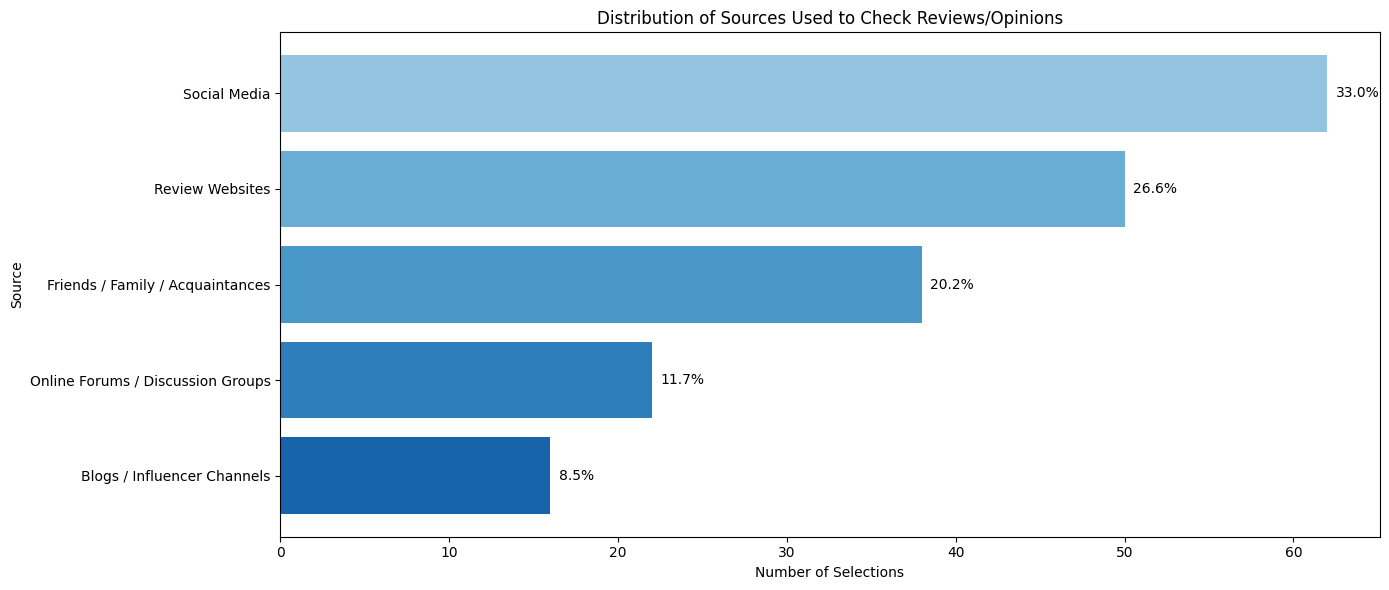

In [14]:
# -------------------------------
# 1️⃣ Standardize review_sources to fixed categories
# -------------------------------
def clean_sources_fixed(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Standard categories
    sources = []
    if any(s in text for s in ['social media', 'facebook', 'instagram', 'tiktok', 'x', 'twitter']):
        sources.append('Social Media')
    if any(s in text for s in ['review website', 'trustpilot', 'tripadvisor']):
        sources.append('Review Websites')
    if any(s in text for s in ['blog', 'influencer']):
        sources.append('Blogs / Influencer Channels')
    if any(s in text for s in ['forum', 'discussion']):
        sources.append('Online Forums / Discussion Groups')
    if any(s in text for s in ['friend', 'family', 'acquaintance']):
        sources.append('Friends / Family / Acquaintances')
    if 'other' in text:
        sources.append('Other')

    # Remove duplicates
    return "|".join(sorted(set(sources)))

df['review_sources_cleaned'] = df['review_sources'].apply(clean_sources_fixed)

# -------------------------------
# 2️⃣ One-hot encode
# -------------------------------
sources_df = df['review_sources_cleaned'].str.get_dummies(sep='|')

# -------------------------------
# 3️⃣ Count totals and percentages (normalized to 100%)
# -------------------------------
sources_counts = sources_df.sum().sort_values(ascending=False)
sources_percent = (sources_counts / sources_counts.sum() * 100).round(1)

sources_summary = pd.DataFrame({
    'Source': sources_counts.index,
    'Number of Selections': sources_counts.values,
    'Percentage (%)': sources_percent.values
})

print("\nDistribution of Sources Used to Check Reviews/Opinions:")
print(sources_summary)

# -------------------------------
# 4️⃣ Horizontal bar chart
# -------------------------------
plt.figure(figsize=(14,6))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(sources_counts)))
bars = plt.barh(sources_counts.index, sources_counts.values, color=colors)

for bar in bars:
    width = bar.get_width()
    pct = width / sources_counts.sum() * 100
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=10)

plt.title("Distribution of Sources Used to Check Reviews/Opinions")
plt.xlabel("Number of Selections")
plt.ylabel("Source")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()


### Transform Ordinal / Likert-Scale Questions:
Properly and safely so that it can later compute means, std, correlations, etc.

In [15]:
# Check unique values in the Likert columns
print(df['reviews_influence_level'].unique())
print(df['trust_users'].unique())
print(df['trust_experts'].unique())
print(df['reviews_importance'].unique())
print(df['negative_brand_impact'].unique())


['Strongly agree' 'Agree' 'Neutral' 'Strongly disagree']
['Neutral' 'Trust' 'Distrust' 'Strongly trust' 'Strongly distrust']
['Distrust' 'Trust' 'Neutral' 'Strongly trust' 'Strongly Distrust']
['Agree' 'Neutral' 'Strongly agree' 'Disagree' 'Strongly disagree']
['To a very great extent' 'To some extent' 'To a great extent'
 'To a small extent' 'Not at all']


In [16]:
# Strip spaces just in case
for col in ['reviews_influence_level', 'trust_users', 'trust_experts', 'reviews_importance', 'negative_brand_impact']:
    df[col] = df[col].astype(str).str.strip()

# Define ordered categories exactly matching your CSV
reviews_influence_order = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
trust_users_order = ["Strongly distrust", "Distrust", "Neutral", "Trust", "Strongly trust"]
trust_experts_order = ["Strongly distrust", "Distrust", "Neutral", "Trust", "Strongly trust"]
reviews_importance_order = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
negative_impact_order = ["Not at all", "To a small extent", "To some extent", "To a great extent", "To a very great extent"]

# Convert to ordered categorical
df['reviews_influence_level'] = pd.Categorical(df['reviews_influence_level'], categories=reviews_influence_order, ordered=True)
df['trust_users'] = pd.Categorical(df['trust_users'], categories=trust_users_order, ordered=True)
df['trust_experts'] = pd.Categorical(df['trust_experts'], categories=trust_experts_order, ordered=True)
df['reviews_importance'] = pd.Categorical(df['reviews_importance'], categories=reviews_importance_order, ordered=True)
df['negative_brand_impact'] = pd.Categorical(df['negative_brand_impact'], categories=negative_impact_order, ordered=True)

# Transform to numeric codes for statistics (1 = lowest, 5 = highest)
df['reviews_influence_level_numeric'] = df['reviews_influence_level'].cat.codes + 1
df['trust_users_numeric'] = df['trust_users'].cat.codes + 1
df['trust_experts_numeric'] = df['trust_experts'].cat.codes + 1
df['reviews_importance_numeric'] = df['reviews_importance'].cat.codes + 1
df['negative_brand_impact_numeric'] = df['negative_brand_impact'].cat.codes + 1

# Frequency / Usage questions (ordinal)
social_media_frequency_order = ["Never", "Rarely", "Once a week", "Several times a week", "Daily"]
check_reviews_frequency_order = ["Never", "Rarely", "Sometimes", "Often", "Always"]

df['social_media_frequency'] = pd.Categorical(df['social_media_frequency'], categories=social_media_frequency_order, ordered=True)
df['check_reviews_frequency'] = pd.Categorical(df['check_reviews_frequency'], categories=check_reviews_frequency_order, ordered=True)

# Numeric codes
df['social_media_frequency_numeric'] = df['social_media_frequency'].cat.codes + 1
df['check_reviews_frequency_numeric'] = df['check_reviews_frequency'].cat.codes + 1

# Now all ordinal / Likert-scale columns are ready for statistics
# Select the relevant columns for H1-H4 (ordinal / Likert + numeric)
columns_to_show = [
    'social_media_frequency', 'social_media_frequency_numeric',
    'check_reviews_frequency', 'check_reviews_frequency_numeric',
    'reviews_influence_level', 'reviews_influence_level_numeric',
    'trust_users', 'trust_users_numeric',
    'trust_experts', 'trust_experts_numeric',
    'reviews_importance', 'reviews_importance_numeric',
    'negative_brand_impact', 'negative_brand_impact_numeric'
]

# Display first 10 rows as a clean table
display(df[columns_to_show].head(10))

,social_media_frequency,social_media_frequency_numeric,check_reviews_frequency,check_reviews_frequency_numeric,reviews_influence_level,reviews_influence_level_numeric,trust_users,trust_users_numeric,trust_experts,trust_experts_numeric,reviews_importance,reviews_importance_numeric,negative_brand_impact,negative_brand_impact_numeric
0,Daily,5,Always,5,Strongly agree,5,Neutral,3,Distrust,2,Agree,4,To a very great extent,5
1,Several times a week,4,Always,5,Agree,4,Trust,4,Trust,4,Agree,4,To a very great extent,5
2,Rarely,2,Always,5,Neutral,3,Trust,4,Neutral,3,Neutral,3,To some extent,3
3,Daily,5,Always,5,Agree,4,Neutral,3,Trust,4,Agree,4,To a great extent,4
4,Daily,5,Always,5,Strongly agree,5,Distrust,2,Distrust,2,Strongly agree,5,To a very great extent,5
5,Daily,5,Sometimes,3,Agree,4,Neutral,3,Trust,4,Agree,4,To a great extent,4
6,Daily,5,Sometimes,3,Agree,4,Trust,4,Trust,4,Agree,4,To a great extent,4
7,Daily,5,Always,5,Agree,4,Trust,4,Neutral,3,Agree,4,To a great extent,4
8,Daily,5,Always,5,Agree,4,Trust,4,Neutral,3,Strongly agree,5,To a great extent,4
9,Daily,5,Always,5,Agree,4,Trust,4,Neutral,3,Agree,4,To a very great extent,5


### Prepare for Hypothesis Testing:
Goal:
Create the correct variables and datasets needed to test H1–H4 using correlations, group comparisons, and frequency tables.

**H1 — Users take comments seriously**
Variables involved:

Q7 → check_reviews_frequency_numeric

Q11 → reviews_influence_level_numeric

Q13 → reviews_importance_numeric

Social media usage:

Q3 → on_social_media (Yes/No)

Q4 → social_media_frequency_numeric

Q5 → platforms_used (dummies)

Q6 → main_platform

In [17]:
# Descriptive statistics for Q7 (frequency & %)
# Frequency and percentage for Q7
q7_counts = df['check_reviews_frequency'].value_counts().sort_index()
q7_percent = (q7_counts / len(df) * 100).round(1)

h1_q7_table = pd.DataFrame({
    'Count': q7_counts,
    'Percentage (%)': q7_percent
})

h1_q7_table

,Count,Percentage (%)
check_reviews_frequency,,
Never,3,3.0
Rarely,4,4.0
Sometimes,15,15.0
Often,31,31.0
Always,47,47.0


In [18]:
# Mean & standard deviation for Q11 and Q13
h1_stats = pd.DataFrame({
    'Variable': ['Influence of reviews (Q11)', 'Importance of reviews (Q13)'],
    'Mean': [
        df['reviews_influence_level_numeric'].mean(),
        df['reviews_importance_numeric'].mean()
    ],
    'Std Dev': [
        df['reviews_influence_level_numeric'].std(),
        df['reviews_importance_numeric'].std()
    ]
}).round(2)

h1_stats

,Variable,Mean,Std Dev
0,Influence of reviews (Q11),3.95,0.87
1,Importance of reviews (Q13),3.85,0.80


In [19]:
# Correlations with social media usage (Spearman)
from scipy.stats import spearmanr

# Q4 vs Q11
corr_q4_q11, p_q4_q11 = spearmanr(
    df['social_media_frequency_numeric'],
    df['reviews_influence_level_numeric'],
    nan_policy='omit'
)

# Q4 vs Q13
corr_q4_q13, p_q4_q13 = spearmanr(
    df['social_media_frequency_numeric'],
    df['reviews_importance_numeric'],
    nan_policy='omit'
)

print("Q4 (Social media frequency) vs Q11 (Influence):",
      round(corr_q4_q11, 2), "p =", round(p_q4_q11, 4))

print("Q4 (Social media frequency) vs Q13 (Importance):",
      round(corr_q4_q13, 2), "p =", round(p_q4_q13, 4))

Q4 (Social media frequency) vs Q11 (Influence): 0.05 p = 0.592
Q4 (Social media frequency) vs Q13 (Importance): 0.05 p = 0.6414


In [20]:
# Q3 (Yes/No) → Group comparison
df.groupby('on_social_media')[
    ['reviews_influence_level_numeric', 'reviews_importance_numeric']
].mean().round(2)

,reviews_influence_level_numeric,reviews_importance_numeric
on_social_media,,
No,3.67,4.00
Yes,3.96,3.85


### H2 — Comments influence purchasing decisions
Variables:

Q9 → influenced_unnecessary_purchase

Q10 → avoided_purchase_negative_review

Q11 → reviews_influence_level_numeric

Optional grouping → social media frequency

In [21]:
# Distribution of Q9 and Q10
q9_dist = df['influenced_unnecessary_purchase'].value_counts(normalize=True) * 100
q10_dist = df['avoided_purchase_negative_review'].value_counts(normalize=True) * 100

pd.DataFrame({
    'Q9 (%)': q9_dist.round(1),
    'Q10 (%)': q10_dist.round(1)
})

,Q9 (%),Q10 (%)
"No, never",25.0,3.0
"Yes, multiple times",15.0,53.0
"Yes, occasionally",60.0,44.0


In [22]:
# Create frequent vs infrequent users
df['usage_group'] = pd.cut(
    df['social_media_frequency_numeric'],
    bins=[0, 3, 5],
    labels=['Infrequent', 'Frequent']
)

In [23]:
# Group comparison (mean influence)
df.groupby('usage_group')['reviews_influence_level_numeric'].mean().round(2)

,reviews_influence_level_numeric
usage_group,
Infrequent,3.25
Frequent,3.98


### H3 — Comments are relevant sources of information
Variables:

Q8 → review_sources dummies

Q12a → trust_users_numeric

Q12b → trust_experts_numeric

Q13 → reviews_importance_numeric

In [24]:
# Frequency of review sources (already encoded)
source_columns = [
    col for col in df.columns
    if col.startswith(('social media', 'review websites', 'blogs', 'online forums', 'friends'))
]

source_usage = df[source_columns].sum().sort_values(ascending=False)

(source_usage / source_usage.sum() * 100).round(1)

,0


In [25]:
# Mean trust and importance
h3_stats = df[[
    'trust_users_numeric',
    'trust_experts_numeric',
    'reviews_importance_numeric'
]].mean().round(2)

h3_stats

,0
trust_users_numeric,3.65
trust_experts_numeric,3.43
reviews_importance_numeric,3.85


In [26]:
# Heavy vs light users comparison
df.groupby('usage_group')[
    ['trust_users_numeric', 'trust_experts_numeric', 'reviews_importance_numeric']
].mean().round(2)

,trust_users_numeric,trust_experts_numeric,reviews_importance_numeric
usage_group,,,
Infrequent,3.75,3.00,3.25
Frequent,3.65,3.45,3.88


### H4 — Brands should monitor comments
Variables:

Q14 → negative_brand_impact_numeric

Q11, Q13 → influence & importance

In [27]:
# Descriptive statistics for Q14
df['negative_brand_impact_numeric'].describe().round(2)

,negative_brand_impact_numeric
count,100.00
mean,4.24
std,0.81
min,1.00
25%,4.00
50%,4.00
75%,5.00
max,5.00


In [28]:
# Correlations (Spearman)
corr_q14_q11, p1 = spearmanr(
    df['negative_brand_impact_numeric'],
    df['reviews_influence_level_numeric'],
    nan_policy='omit'
)

corr_q14_q13, p2 = spearmanr(
    df['negative_brand_impact_numeric'],
    df['reviews_importance_numeric'],
    nan_policy='omit'
)

print("Q14 vs Q11:", round(corr_q14_q11, 2), "p =", round(p1, 4))
print("Q14 vs Q13:", round(corr_q14_q13, 2), "p =", round(p2, 4))


Q14 vs Q11: 0.22 p = 0.0307
Q14 vs Q13: 0.23 p = 0.02


In [29]:
# Group comparison (frequent vs infrequent)
df.groupby('usage_group')['negative_brand_impact_numeric'].mean().round(2)

,negative_brand_impact_numeric
usage_group,
Infrequent,4.00
Frequent,4.25


### Formal Hypothesis Testing & Decisions

We explicitly test each hypothesis using appropriate statistics, p-values, and decision rules.

Decision rule

p < 0.05 → statistically significant relationship

p ≥ 0.05 → not significant

In [30]:
# H1 — Users take comments seriously
# H1a: Relationship between social media frequency (Q4) and influence (Q11)
from scipy.stats import spearmanr

h1_corr_q4_q11, h1_p_q4_q11 = spearmanr(
    df['social_media_frequency_numeric'],
    df['reviews_influence_level_numeric'],
    nan_policy='omit'
)

h1_corr_q4_q11, h1_p_q4_q11

(np.float64(0.0542296767855034), np.float64(0.5920460971858559))

In [31]:
# H1b: Relationship between social media frequency (Q4) and importance (Q13)
h1_corr_q4_q13, h1_p_q4_q13 = spearmanr(
    df['social_media_frequency_numeric'],
    df['reviews_importance_numeric'],
    nan_policy='omit'
)

h1_corr_q4_q13, h1_p_q4_q13

(np.float64(0.04713654491708151), np.float64(0.6414315300535056))

In [32]:
# H1c: Social media users vs non-users (Q3)
df.groupby('on_social_media')[
    ['reviews_influence_level_numeric', 'reviews_importance_numeric']
].mean().round(2)

,reviews_influence_level_numeric,reviews_importance_numeric
on_social_media,,
No,3.67,4.00
Yes,3.96,3.85


In [33]:
# H2 — Comments influence purchasing decisions
# H2a: Influence level differs by purchasing behavior (Q9)
df.groupby('influenced_unnecessary_purchase')[
    'reviews_influence_level_numeric'
].mean().round(2)

,reviews_influence_level_numeric
influenced_unnecessary_purchase,
"No, never",3.48
"Yes, multiple times",4.07
"Yes, occasionally",4.12


In [34]:
# H2b: Influence level differs by avoidance behavior (Q10)
df.groupby('avoided_purchase_negative_review')[
    'reviews_influence_level_numeric'
].mean().round(2)

,reviews_influence_level_numeric
avoided_purchase_negative_review,
"No, never",2.00
"Yes, multiple times",4.34
"Yes, occasionally",3.61


In [35]:
# Optional chi-square test (categorical association)
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df['influenced_unnecessary_purchase'],
    df['usage_group']
)

chi2, p, dof, expected = chi2_contingency(contingency)

chi2, p

(np.float64(1.736111111111111), np.float64(0.41976696977310424))

In [36]:
# H3 — Comments are relevant sources of information
# Trust & importance (means)
df[['trust_users_numeric',
    'trust_experts_numeric',
    'reviews_importance_numeric']].mean().round(2)

,0
trust_users_numeric,3.65
trust_experts_numeric,3.43
reviews_importance_numeric,3.85


In [37]:
# Heavy vs light users comparison
df.groupby('usage_group')[
    ['trust_users_numeric',
     'trust_experts_numeric',
     'reviews_importance_numeric']
].mean().round(2)

,trust_users_numeric,trust_experts_numeric,reviews_importance_numeric
usage_group,,,
Infrequent,3.75,3.00,3.25
Frequent,3.65,3.45,3.88


In [38]:
# H4 — Brands should monitor comments
# Correlation with influence & importance
h4_corr_q14_q11, p1 = spearmanr(
    df['negative_brand_impact_numeric'],
    df['reviews_influence_level_numeric'],
    nan_policy='omit'
)

h4_corr_q14_q13, p2 = spearmanr(
    df['negative_brand_impact_numeric'],
    df['reviews_importance_numeric'],
    nan_policy='omit'
)

h4_corr_q14_q11, p1, h4_corr_q14_q13, p2

(np.float64(0.21622935520386408),
 np.float64(0.03071547375542216),
 np.float64(0.2323849691805774),
 np.float64(0.01998762787797042))

### Publication-Ready Tables (APA / Thesis Style)

In [39]:
# Table 1: Descriptive statistics (Likert variables)
desc_table = pd.DataFrame({
    'Variable': [
        'Influence of reviews (Q11)',
        'Importance of reviews (Q13)',
        'Trust in users (Q12a)',
        'Trust in experts (Q12b)',
        'Negative brand impact (Q14)'
    ],
    'Mean': [
        df['reviews_influence_level_numeric'].mean(),
        df['reviews_importance_numeric'].mean(),
        df['trust_users_numeric'].mean(),
        df['trust_experts_numeric'].mean(),
        df['negative_brand_impact_numeric'].mean()
    ],
    'Std. Dev': [
        df['reviews_influence_level_numeric'].std(),
        df['reviews_importance_numeric'].std(),
        df['trust_users_numeric'].std(),
        df['trust_experts_numeric'].std(),
        df['negative_brand_impact_numeric'].std()
    ]
}).round(2)

desc_table

,Variable,Mean,Std. Dev
0,Influence of reviews (Q11),3.95,0.87
1,Importance of reviews (Q13),3.85,0.80
2,Trust in users (Q12a),3.65,0.76
3,Trust in experts (Q12b),3.43,0.86
4,Negative brand impact (Q14),4.24,0.81


In [40]:
# Table 2: Correlation results (H1 & H4)
correlation_table = pd.DataFrame({
    'Relationship': [
        'Social media frequency ↔ Influence (H1)',
        'Social media frequency ↔ Importance (H1)',
        'Brand impact ↔ Influence (H4)',
        'Brand impact ↔ Importance (H4)'
    ],
    'Spearman r': [
        h1_corr_q4_q11,
        h1_corr_q4_q13,
        h4_corr_q14_q11,
        h4_corr_q14_q13
    ],
    'p-value': [
        h1_p_q4_q11,
        h1_p_q4_q13,
        p1,
        p2
    ]
}).round(3)

correlation_table

,Relationship,Spearman r,p-value
0,Social media frequency ↔ Influence (H1),0.054,0.592
1,Social media frequency ↔ Importance (H1),0.047,0.641
2,Brand impact ↔ Influence (H4),0.216,0.031
3,Brand impact ↔ Importance (H4),0.232,0.020


### Visualizations for Hypothesis Results

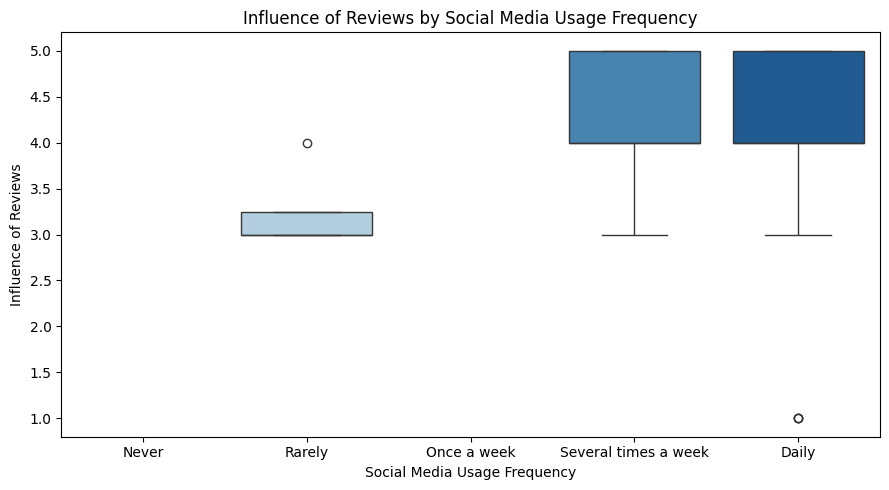

In [41]:
# H1: Influence vs social media frequency
plt.figure(figsize=(9,5))
sns.boxplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    palette="Blues"
)
plt.title("Influence of Reviews by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()


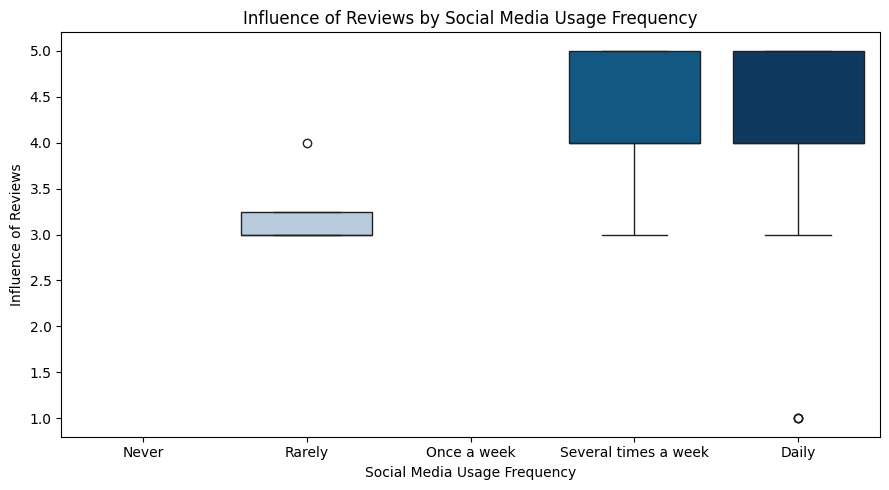

In [42]:
# H1: Influence vs social media frequency
blue_shades = ['#dbe9f6', '#b3cde3', '#6497b1', '#005b96', '#03396c']

plt.figure(figsize=(9,5))

sns.boxplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    palette=blue_shades
)

plt.title("Influence of Reviews by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()


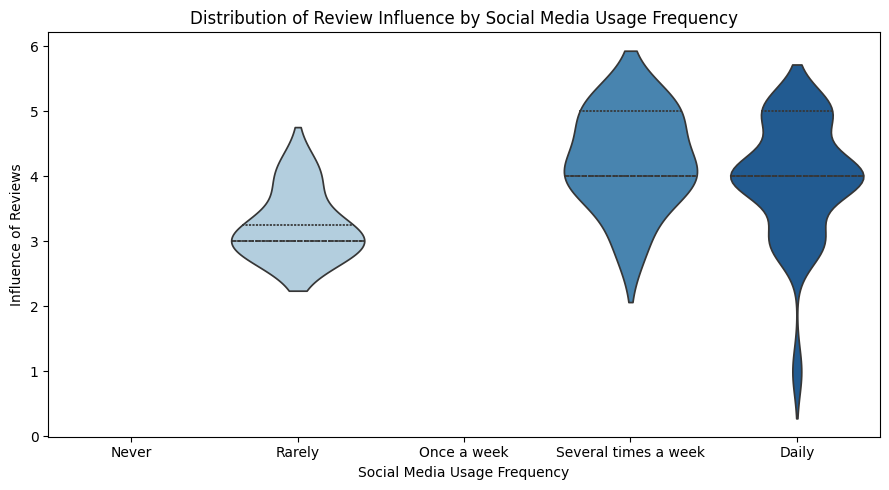

In [43]:
# OPTION 1 — H1: Violin Plot (Distribution + Density)
# Best when: you want to show shape, spread, and median together.

plt.figure(figsize=(9,5))

sns.violinplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    palette='Blues',
    inner='quartile'
)

plt.title("Distribution of Review Influence by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()

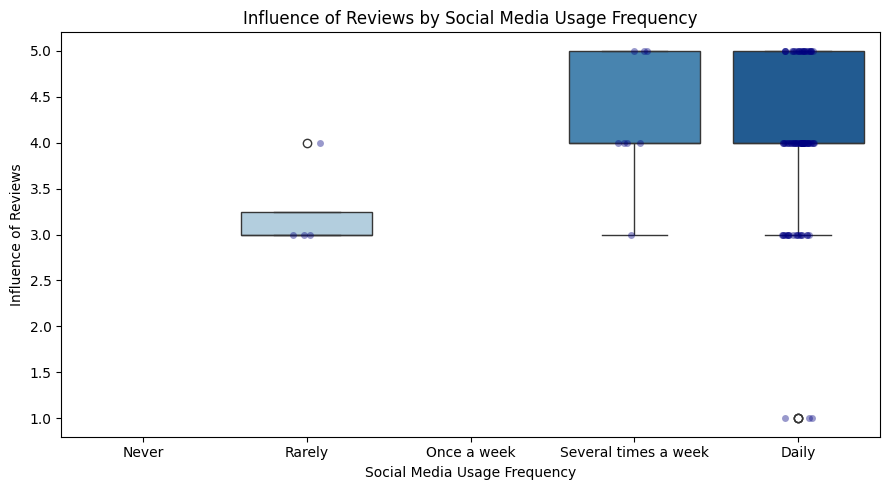

In [44]:
# OPTION 2 — H1: Boxplot + Jittered Points (Very Strong)
# Best when: you want transparency and individual responses visible.

plt.figure(figsize=(9,5))

sns.boxplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    palette='Blues'
)

sns.stripplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    color='navy',
    alpha=0.4,
    jitter=True
)

plt.title("Influence of Reviews by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()

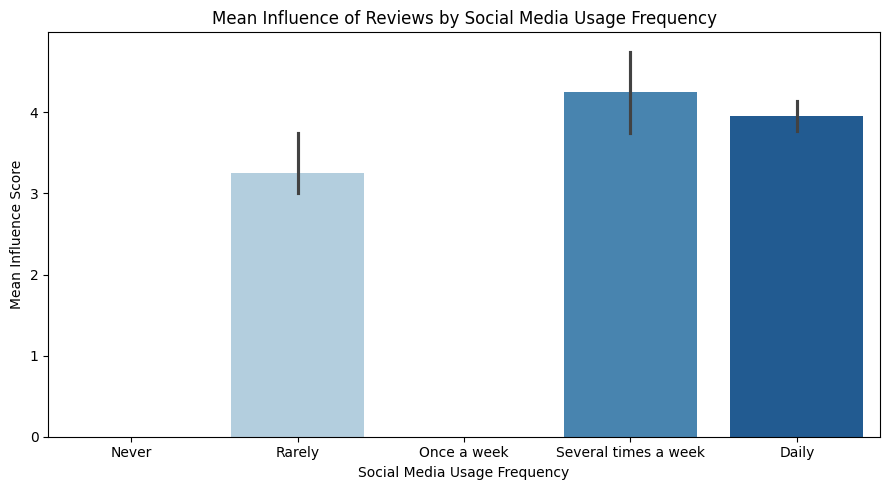

In [45]:
# OPTION 3 — H1: Mean Bar Chart with Confidence Interval
# Best when: you want something clean, simple, and managerial.

plt.figure(figsize=(9,5))

sns.barplot(
    x='social_media_frequency',
    y='reviews_influence_level_numeric',
    data=df,
    order=["Never", "Rarely", "Once a week", "Several times a week", "Daily"],
    palette=sns.color_palette("Blues", 5),
    ci=95
)

plt.title("Mean Influence of Reviews by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Mean Influence Score")
plt.tight_layout()
plt.show()

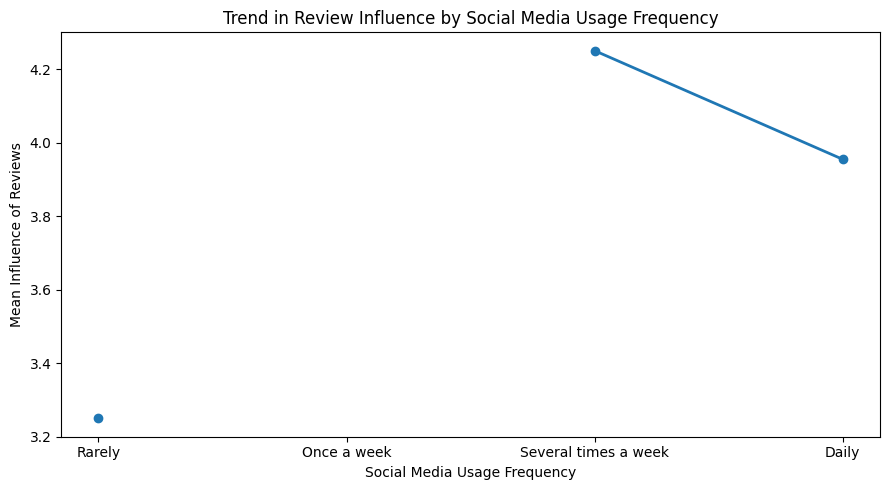

In [46]:
# OPTION 4 — H1: Line Plot of Means (Trend-Focused)
# Best when: you want to emphasize directional trend (H1 logic).

mean_influence = (
    df.groupby('social_media_frequency')['reviews_influence_level_numeric']
      .mean()
      .reindex(["Never", "Rarely", "Once a week", "Several times a week", "Daily"])
)

plt.figure(figsize=(9,5))
plt.plot(
    mean_influence.index,
    mean_influence.values,
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

plt.title("Trend in Review Influence by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Mean Influence of Reviews")
plt.tight_layout()
plt.show()

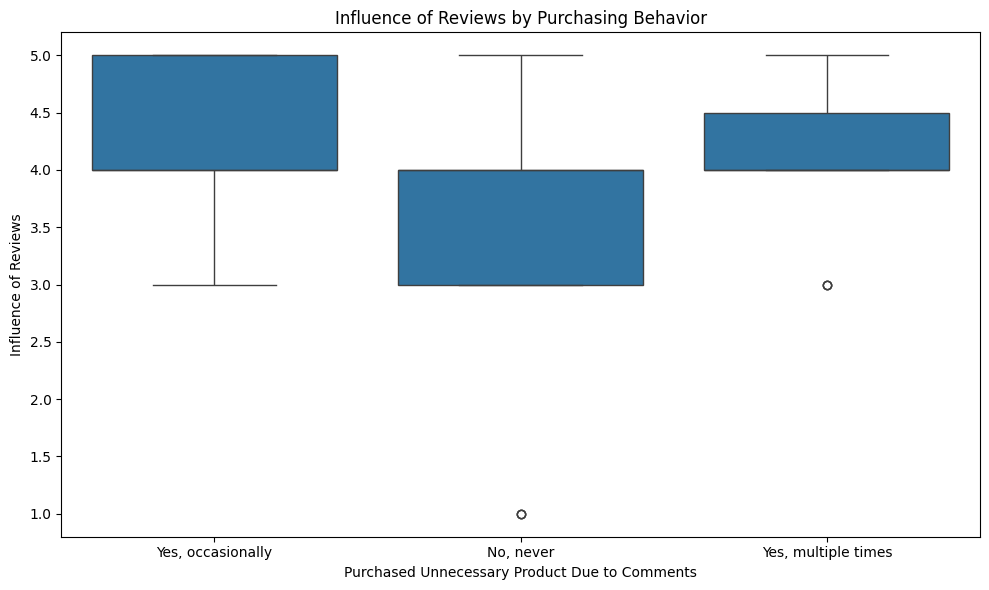

In [47]:
# H2: Purchasing behavior vs influence
plt.figure(figsize=(10,6))
sns.boxplot(
    x='influenced_unnecessary_purchase',
    y='reviews_influence_level_numeric',
    data=df
)
plt.title("Influence of Reviews by Purchasing Behavior")
plt.xlabel("Purchased Unnecessary Product Due to Comments")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()

In [48]:
# H3: Posts and comments are perceived as relevant sources of information.
import seaborn as sns
import matplotlib.pyplot as plt

# Select variables for H3
h3_df = df[['usage_group',
            'trust_users_numeric',
            'trust_experts_numeric',
            'reviews_importance_numeric']]

# Convert to long format
h3_long = h3_df.melt(
    id_vars='usage_group',
    value_vars=[
        'trust_users_numeric',
        'trust_experts_numeric',
        'reviews_importance_numeric'
    ],
    var_name='Variable',
    value_name='Score'
)

# Rename for nicer labels
h3_long['Variable'] = h3_long['Variable'].replace({
    'trust_users_numeric': 'Trust in users',
    'trust_experts_numeric': 'Trust in experts',
    'reviews_importance_numeric': 'Importance of reviews'
})


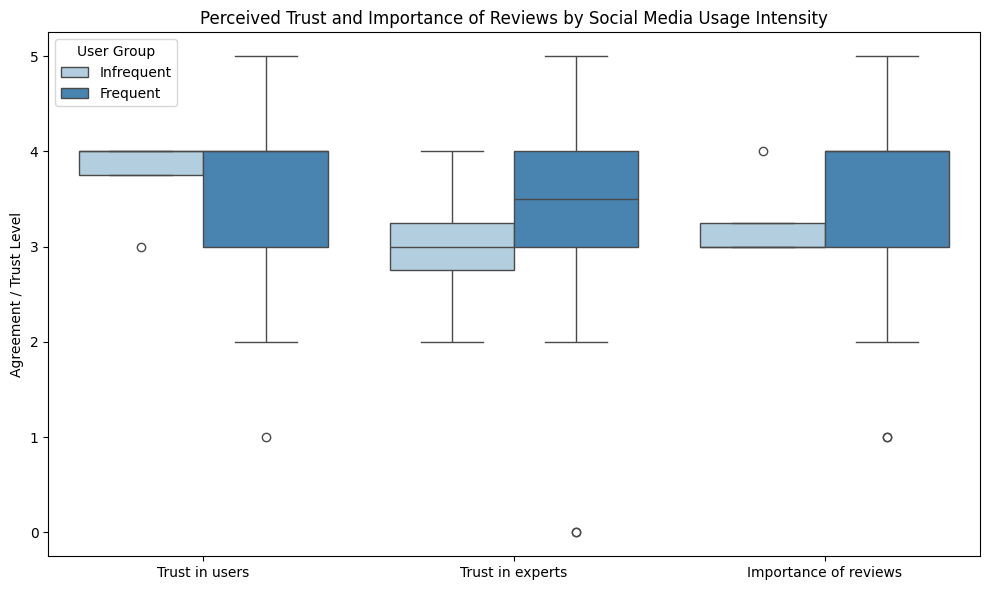

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=h3_long,
    x='Variable',
    y='Score',
    hue='usage_group',
    palette='Blues'
)

plt.title("Perceived Trust and Importance of Reviews by Social Media Usage Intensity")
plt.xlabel("")
plt.ylabel("Agreement / Trust Level")
plt.legend(title="User Group")
plt.tight_layout()
plt.show()


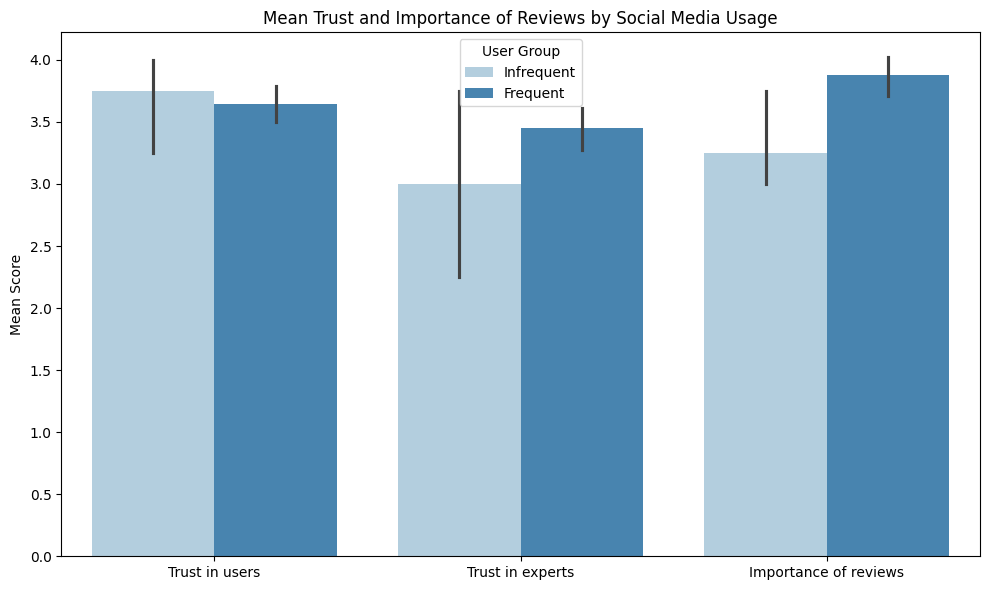

In [50]:
# Optional (Cleaner alternative): Mean bar chart with CI
# If you prefer simpler visuals:
plt.figure(figsize=(10,6))

sns.barplot(
    data=h3_long,
    x='Variable',
    y='Score',
    hue='usage_group',
    palette='Blues',
    ci=95
)

plt.title("Mean Trust and Importance of Reviews by Social Media Usage")
plt.xlabel("")
plt.ylabel("Mean Score")
plt.legend(title="User Group")
plt.tight_layout()
plt.show()


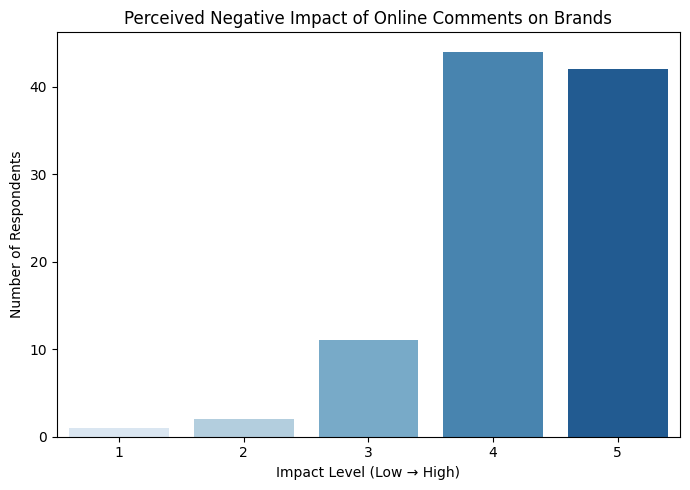

In [51]:
# H4 Visualization 1 — Distribution of perceived brand impact
plt.figure(figsize=(7,5))

sns.countplot(
    x='negative_brand_impact_numeric',
    data=df,
    palette='Blues'
)

plt.title("Perceived Negative Impact of Online Comments on Brands")
plt.xlabel("Impact Level (Low → High)")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

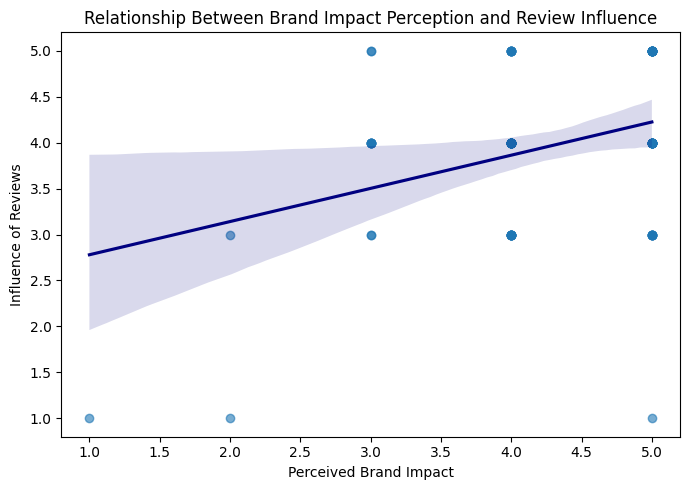

In [52]:
# H4 Visualization 2 — Relationship with influence & importance
# Scatter + trend line (best for correlations)
plt.figure(figsize=(7,5))

sns.regplot(
    x='negative_brand_impact_numeric',
    y='reviews_influence_level_numeric',
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'navy'}
)

plt.title("Relationship Between Brand Impact Perception and Review Influence")
plt.xlabel("Perceived Brand Impact")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()

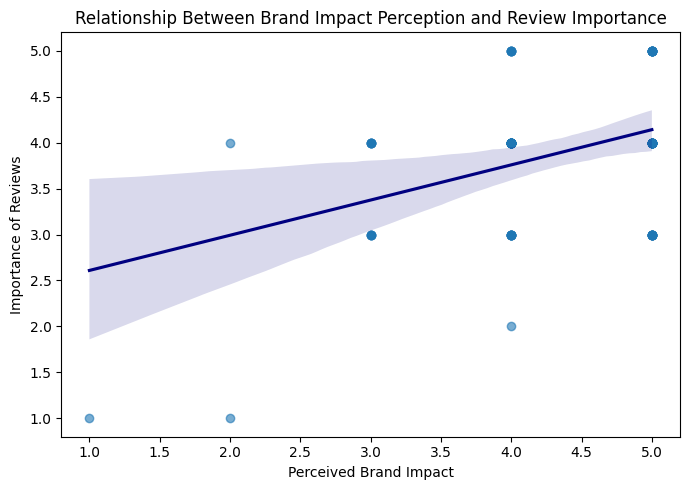

In [53]:
# Second plot: Brand impact vs importance
plt.figure(figsize=(7,5))

sns.regplot(
    x='negative_brand_impact_numeric',
    y='reviews_importance_numeric',
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'navy'}
)

plt.title("Relationship Between Brand Impact Perception and Review Importance")
plt.xlabel("Perceived Brand Impact")
plt.ylabel("Importance of Reviews")
plt.tight_layout()
plt.show()

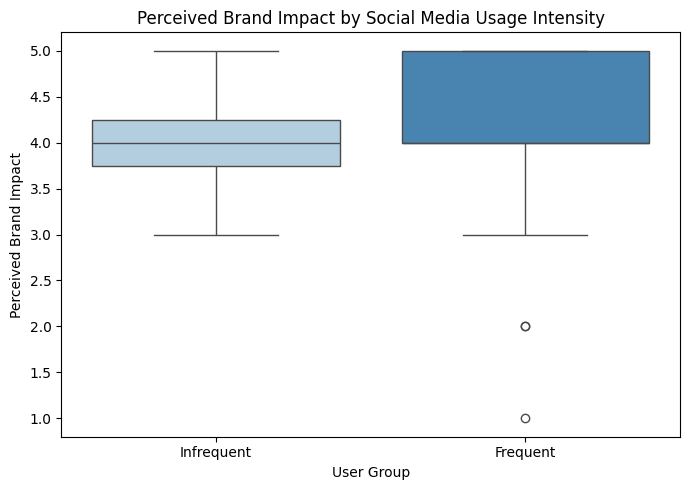

In [54]:
# Optional (Very clean alternative): Group comparison
plt.figure(figsize=(7,5))

sns.boxplot(
    x='usage_group',
    y='negative_brand_impact_numeric',
    data=df,
    palette='Blues'
)

plt.title("Perceived Brand Impact by Social Media Usage Intensity")
plt.xlabel("User Group")
plt.ylabel("Perceived Brand Impact")
plt.tight_layout()
plt.show()

### Correlation Matrix (VERY IMPORTANT for H1 & H4)

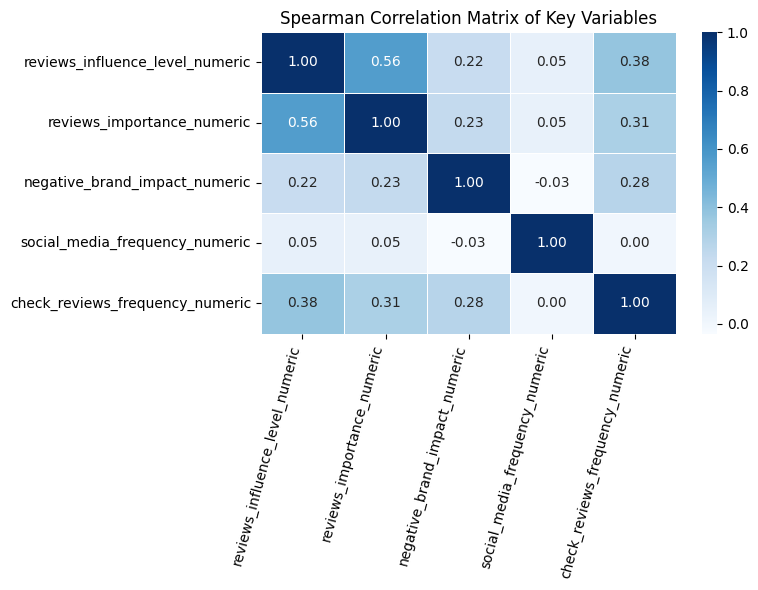

In [55]:
# H1: Correlation Matrix (Users take comments seriously)
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = [
    'reviews_influence_level_numeric',
    'reviews_importance_numeric',
    'negative_brand_impact_numeric',
    'social_media_frequency_numeric',
    'check_reviews_frequency_numeric'
]

corr_matrix = df[corr_vars].corr(method='spearman')

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

# Rotate labels to 75 degrees
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)

plt.title("Spearman Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()


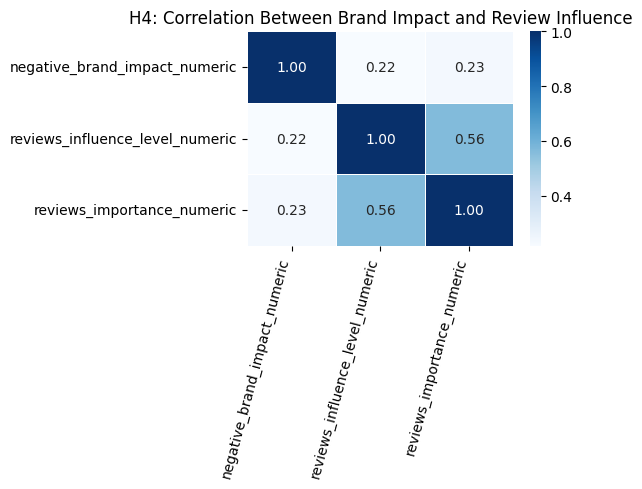

In [56]:
# H4-specific correlation matrix (clean & academic)
# H4: Correlation matrix focused on brand impact
h4_vars = [
    'negative_brand_impact_numeric',
    'reviews_influence_level_numeric',
    'reviews_importance_numeric'
]

h4_corr = df[h4_vars].corr(method='spearman')

plt.figure(figsize=(6,5))
sns.heatmap(
    h4_corr,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

# Rotate labels to 75 degrees
plt.xticks(rotation=75, ha='right')
plt.yticks(rotation=0)

plt.title("H4: Correlation Between Brand Impact and Review Influence")
plt.tight_layout()
plt.show()

✅ Why this is strong

Uses Spearman → correct for ordinal/Likert data

Shows direction + strength

Easy to reference in Results and Discussion

Other Option:
Scatter Plot with Trend Line (Ordinal-friendly)

Great for visually supporting correlations.

🔹 Example: H1

Social media frequency vs influence of reviews



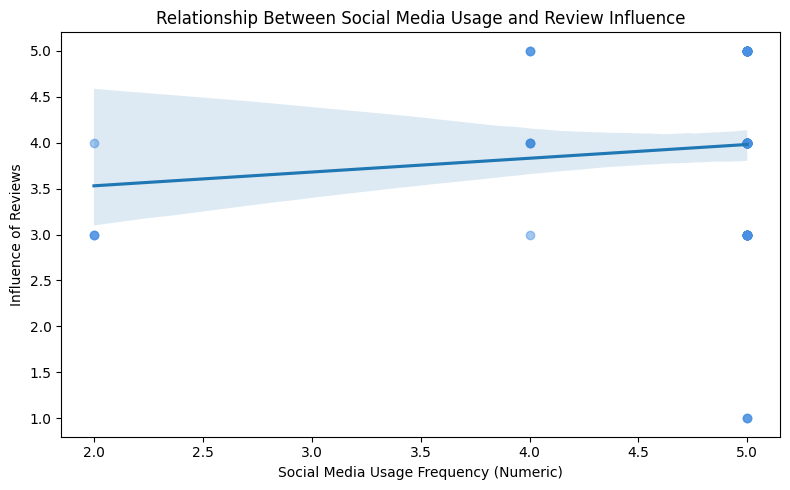

In [57]:
#Example: H1: Social media frequency vs influence of reviews
plt.figure(figsize=(8,5))
sns.regplot(
    x='social_media_frequency_numeric',
    y='reviews_influence_level_numeric',
    data=df,
    scatter_kws={'alpha':0.5, 'color':'#4a90e2'},
    line_kws={'color':'#1f77b4'}
)

plt.title("Relationship Between Social Media Usage and Review Influence")
plt.xlabel("Social Media Usage Frequency (Numeric)")
plt.ylabel("Influence of Reviews")
plt.tight_layout()
plt.show()


✅ Shows trend, not just group differences
✅ Very intuitive for readers

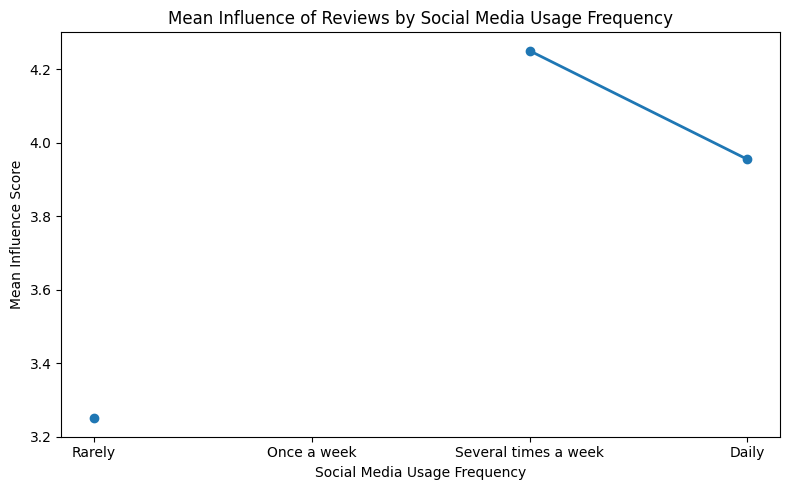

In [58]:
# Mean Comparison Plot (Excellent for Hypotheses)
# This is a clean alternative to boxplots.
# Example: H1
mean_values = (
    df.groupby('social_media_frequency')['reviews_influence_level_numeric']
      .mean()
      .reindex(["Never", "Rarely", "Once a week", "Several times a week", "Daily"])
)

plt.figure(figsize=(8,5))
plt.plot(
    mean_values.index,
    mean_values.values,
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

plt.title("Mean Influence of Reviews by Social Media Usage Frequency")
plt.xlabel("Social Media Usage Frequency")
plt.ylabel("Mean Influence Score")
plt.tight_layout()
plt.show()


# ✅ Perfect to support acceptance/rejection of H1
# ✅ Very readable in thesis documents



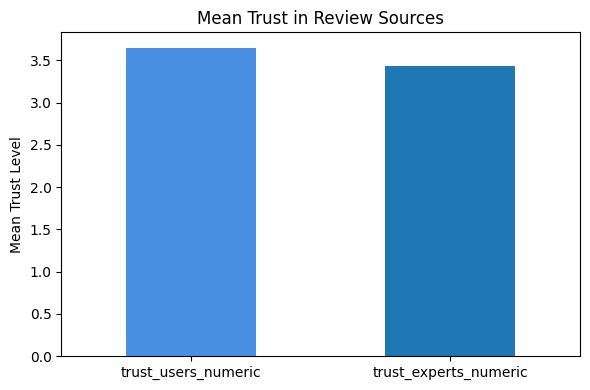

In [59]:
# Grouped Bar Chart (Great for H3)
# Useful when comparing trust vs importance.
# Example: Trust in users vs experts
trust_means = df[['trust_users_numeric', 'trust_experts_numeric']].mean()

plt.figure(figsize=(6,4))
trust_means.plot(
    kind='bar',
    color=['#4a90e2', '#1f77b4']
)

plt.title("Mean Trust in Review Sources")
plt.ylabel("Mean Trust Level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ✅ Very strong for H3
# ✅ Clean, interpretable, academic


**When to use what (Quick Guide)**

Hypothesis	Best Visuals:

H1	Boxplot + correlation matrix

H2	Bar charts (Yes/No) + chi-square table

H3	Bar charts + grouped means

H4	Correlation matrix + scatter

Hypothesis-by-hypothesis check
🔹 H1 – Users take comments seriously

Goal
Show that reviews/comments are influential and important, especially among active social media users.

You have / should have:

✔ Boxplot:

reviews_influence_level_numeric × social_media_frequency

✔ Correlation matrix:

Q4 (social media frequency)

Q7 (checking reviews)

Q11 (influence)

Q13 (importance)

Best visuals

Boxplot (you already have)

Correlation heatmap (Spearman)

✅ Conclusion: H1 is fully covered.

🔹 H2 – Comments influence purchasing decisions

Goal
Show that comments lead to buying or not buying.

You have / should have:

✔ Bar charts:

Q9 (Yes/No – purchased due to comments)

Q10 (Yes/No – avoided purchase)

✔ Optional grouping:

Frequent vs infrequent social media users

✔ Chi-square test (table, not visualization-heavy)

Best visuals

Bar charts (counts / percentages)

Chi-square results in a table (not necessarily a plot)

✅ Conclusion: You are doing exactly what is expected.

🔹 H3 – Comments are relevant sources of information

Goal
Demonstrate that users trust and rely on comments as information sources.

You have / should have:

✔ Bar chart:

Q8 (sources of information)

✔ Means comparison:

Q12a (trust users)

Q12b (trust experts)

Q13 (importance)

✔ Grouping:

Heavy vs light users

Best visuals

Bar charts (sources)

Bar chart of mean Likert scores by group
(or boxplots)

✅ Conclusion: Strong and well-aligned with your objectives.

🔹 H4 – Brands should monitor comments

Goal
Show perceived risk and crisis potential.

You have / should have:

✔ Correlation:

Q14 × Q11

Q14 × Q13

✔ Optional scatter plot (with jitter)

Best visuals

Correlation matrix

Scatter plot (optional, explanatory)

✅ Conclusion: More than sufficient for H4.

Your quick guide — validated ✅

Your summary is correct and professional:

Hypothesis	Best Visuals
H1	Boxplot + correlation matrix
H2	Bar charts (Yes/No) + chi-square table
H3	Bar charts + grouped means
H4	Correlation matrix + scatter

I would keep this exactly as it is in your methodology or analysis chapter.

One important academic reassurance

🔹 Not every hypothesis needs a complex visualization.
Tables + 1–2 clear plots per hypothesis is ideal.

🔹 Examiners value:

clarity

methodological alignment

correct use of scales

You have all three.

Optional (only if you want to polish further)

If you want to upgrade presentation, not methodology:

Add one combined correlation heatmap for:

Q11, Q13, Q14, Q4, Q7

Use consistent blue palette across all figures (which you already do)

But again: optional.

✅ Final verdict

You can confidently say:

“The hypotheses were tested using descriptive statistics, correlation analysis, and group comparisons, supported by appropriate visualizations aligned with the measurement scales of the questionnaire.”

If you want, next I can:

help you write the Results section text (academic tone)

help you interpret results hypothesis by hypothesis

help you decide which plots go in appendix vs main body

Just tell me.